# Exploratory Data Analysis (EDA) — Face Shape Dataset

**Dataset:** `dataset/men/{training_set,testing_set}/{ovale,rectangular,round,square}`

Notebook ini **murni EDA** (tanpa training/modeling). Tujuannya memahami dataset secara menyeluruh
sebelum masuk ke tahap modeling: struktur, distribusi, kualitas gambar, dan potensi masalah data.

> Ubah `DATA_DIR` di bawah sesuai lokasi folder `dataset/men` di komputer kamu.


In [1]:
# Ubah path ini sesuai lokasi dataset kamu
DATA_DIR = "./dataset/men"   # contoh: "~/Downloads/2/dataset/men"


In [2]:
# Install dependency (jalankan sekali saja jika belum ada)
# !pip install pandas numpy matplotlib seaborn pillow


### Import Library

In [3]:
import os
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")
%matplotlib inline


---
## 1. Kumpulkan Metadata Semua Gambar

Membaca tiap gambar untuk mendapatkan ukuran, resolusi, mode warna, ukuran file, dan menandai
gambar yang gagal dibuka (corrupt) tanpa menghentikan proses.


In [4]:
base = Path(DATA_DIR)
records = []
corrupt_files = []

for split in ["training_set", "testing_set"]:
    split_dir = base / split
    if not split_dir.exists():
        print(f"⚠️ Folder tidak ditemukan: {split_dir}")
        continue
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls = cls_dir.name
        for f in cls_dir.iterdir():
            if f.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                continue
            try:
                with Image.open(f) as img:
                    img.verify()  # cek integritas file
                with Image.open(f) as img:
                    w, h = img.size
                    mode = img.mode
                file_size_kb = f.stat().st_size / 1024
                records.append({
                    "split": split,
                    "class": cls,
                    "filename": f.name,
                    "width": w,
                    "height": h,
                    "aspect_ratio": round(w / h, 3),
                    "megapixels": round((w * h) / 1_000_000, 3),
                    "mode": mode,
                    "file_size_kb": round(file_size_kb, 1),
                    "filepath": str(f),
                })
            except Exception as e:
                corrupt_files.append({"filepath": str(f), "error": str(e)})

df = pd.DataFrame(records)
print(f"Total gambar valid terbaca : {len(df)}")
print(f"Total gambar corrupt/gagal : {len(corrupt_files)}")
if corrupt_files:
    display(pd.DataFrame(corrupt_files))
df.head()


Total gambar valid terbaca : 1312
Total gambar corrupt/gagal : 0


,split,class,filename,width,height,aspect_ratio,megapixels,mode,file_size_kb,filepath
0,training_set,ovale,ovale 460.jpg,184,274,0.672,0.050,RGB,6.4,dataset/men/training_set/ovale/ovale 460.jpg
1,training_set,ovale,ovale 306.jpg,190,265,0.717,0.050,RGB,6.7,dataset/men/training_set/ovale/ovale 306.jpg
2,training_set,ovale,ovale 448.jpg,185,273,0.678,0.051,RGB,9.6,dataset/men/training_set/ovale/ovale 448.jpg
3,training_set,ovale,ovale 299.jpg,186,270,0.689,0.050,RGB,6.1,dataset/men/training_set/ovale/ovale 299.jpg
4,training_set,ovale,ovale 298.jpg,300,168,1.786,0.050,RGB,11.2,dataset/men/training_set/ovale/ovale 298.jpg


---
## 2. Ringkasan Umum Dataset


In [5]:
print("=== Jumlah gambar per split & kelas ===")
summary = df.groupby(["split", "class"]).size().unstack()
display(summary)
summary["total"] = summary.sum(axis=1)
print(f"\nTotal per split: train={summary.loc['training_set','total'] if 'training_set' in summary.index else 0}, "
      f"test={summary.loc['testing_set','total'] if 'testing_set' in summary.index else 0}")

print("\n=== Mode warna ===")
print(df["mode"].value_counts())

print("\n=== Statistik ukuran file (KB) ===")
display(df["file_size_kb"].describe())

print("\n=== Statistik resolusi ===")
display(df[["width", "height", "megapixels"]].describe())

counts = df.groupby("class").size()
print(f"\nRasio imbalance antar kelas (max/min): {counts.max()/counts.min():.3f}")
print(f"Jumlah kelas unik: {df['class'].nunique()} -> {sorted(df['class'].unique())}")


=== Jumlah gambar per split & kelas ===


class,ovale,rectangular,round,square
split,,,,
testing_set,112,111,63,99
training_set,234,194,278,221



Total per split: train=927, test=385

=== Mode warna ===
mode
RGB    1312
Name: count, dtype: int64

=== Statistik ukuran file (KB) ===


count    1312.000000
mean       30.072561
std       106.221649
min         1.900000
25%         5.600000
50%         6.500000
75%        12.850000
max      2011.200000
Name: file_size_kb, dtype: float64


=== Statistik resolusi ===


,width,height,megapixels
count,1312.000000,1312.000000,1312.000000
mean,323.207317,349.976372,0.199956
std,285.053634,332.603217,0.618873
min,79.000000,85.000000,0.007000
25%,194.000000,209.750000,0.050000
50%,225.000000,255.500000,0.050000
75%,300.000000,281.000000,0.051000
max,2995.000000,3034.000000,8.970000



Rasio imbalance antar kelas (max/min): 1.134
Jumlah kelas unik: 4 -> ['ovale', 'rectangular', 'round', 'square']


---
## 3. Distribusi Kelas


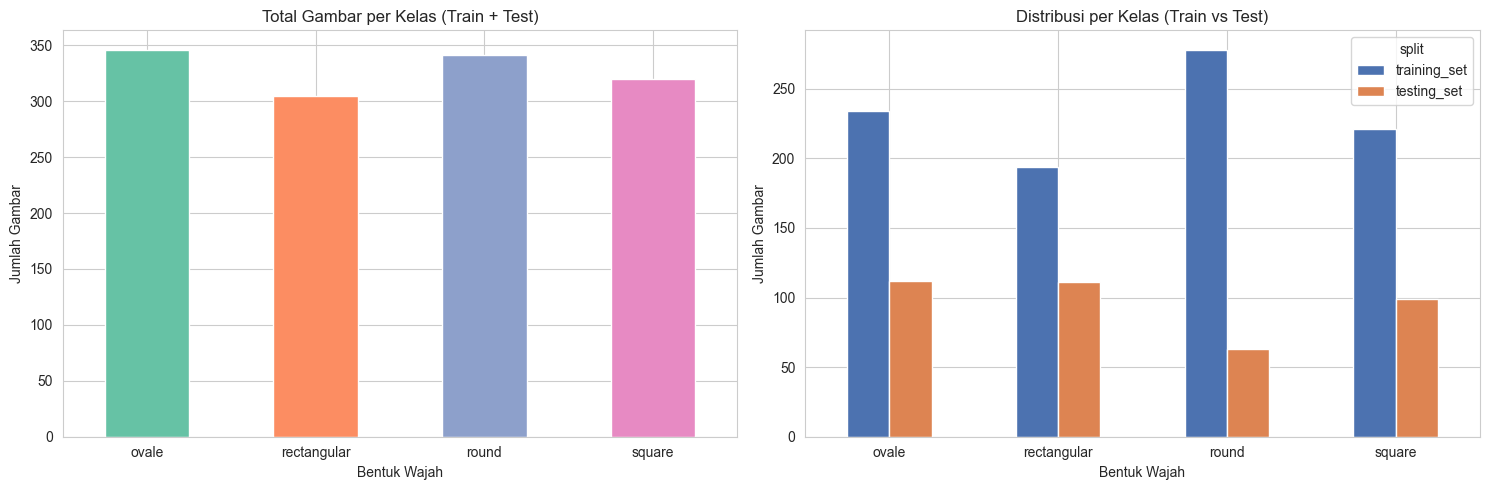

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total per kelas
df["class"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", df["class"].nunique()))
axes[0].set_title("Total Gambar per Kelas (Train + Test)")
axes[0].set_xlabel("Bentuk Wajah")
axes[0].set_ylabel("Jumlah Gambar")
axes[0].tick_params(axis="x", rotation=0)

# Per split
pivot = df.groupby(["class", "split"]).size().unstack()
cols_order = [c for c in ["training_set", "testing_set"] if c in pivot.columns]
pivot[cols_order].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Distribusi per Kelas (Train vs Test)")
axes[1].set_xlabel("Bentuk Wajah")
axes[1].set_ylabel("Jumlah Gambar")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [7]:
# Proporsi test set per kelas — untuk cek apakah split-nya seimbang antar kelas
prop = (pivot["testing_set"] / (pivot["training_set"] + pivot["testing_set"]) * 100).round(1)
print("Proporsi data yang dialokasikan ke testing_set per kelas (%):")
print(prop)


Proporsi data yang dialokasikan ke testing_set per kelas (%):
class
ovale          32.4
rectangular    36.4
round          18.5
square         30.9
dtype: float64


**Insight:** Perhatikan apakah proporsi testing_set konsisten antar kelas. Jika ada kelas dengan
proporsi jauh berbeda dari kelas lain, evaluasi model nanti sebaiknya memakai metrik per-kelas
(precision/recall/F1), bukan hanya akurasi keseluruhan.

---
## 4. Resolusi & Aspect Ratio


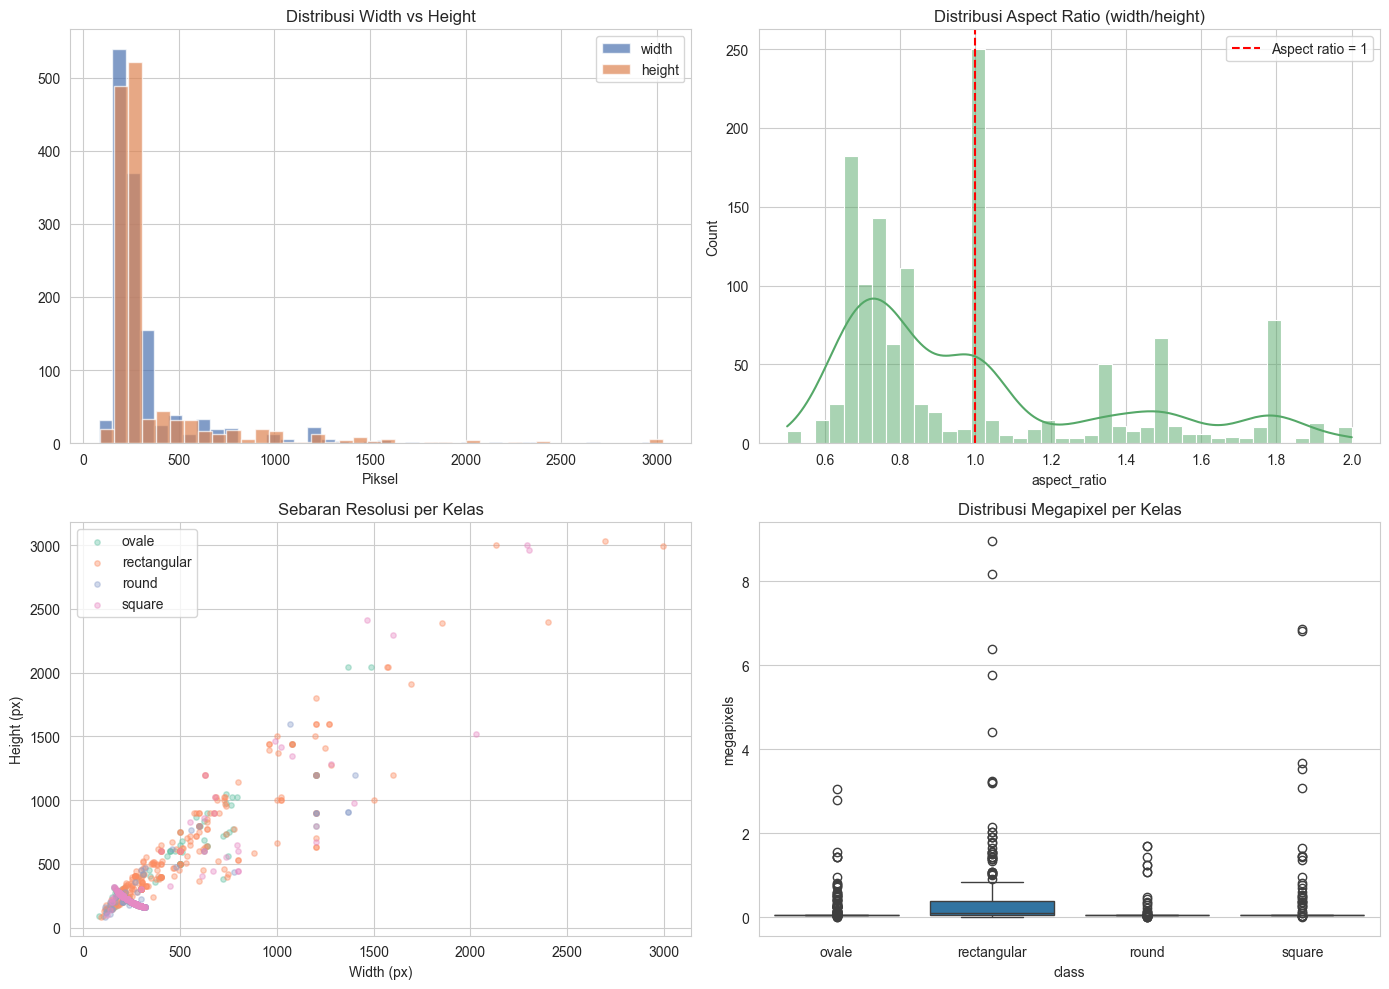

Jumlah kombinasi resolusi unik: 426

Top 10 resolusi paling umum:
width  height
225    225       138
183    275        91
194    259        54
300    168        49
275    183        46
205    246        37
259    194        29
201    251        27
299    168        24
300    300        20
dtype: int64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram width & height
axes[0,0].hist(df["width"], bins=40, alpha=0.7, label="width", color="#4C72B0")
axes[0,0].hist(df["height"], bins=40, alpha=0.7, label="height", color="#DD8452")
axes[0,0].set_title("Distribusi Width vs Height")
axes[0,0].set_xlabel("Piksel")
axes[0,0].legend()

# Aspect ratio
sns.histplot(df["aspect_ratio"], bins=40, kde=True, ax=axes[0,1], color="#55A868")
axes[0,1].axvline(1.0, color="red", linestyle="--", label="Aspect ratio = 1")
axes[0,1].set_title("Distribusi Aspect Ratio (width/height)")
axes[0,1].legend()

# Scatter resolusi per kelas
for cls, color in zip(sorted(df["class"].unique()), sns.color_palette("Set2", df["class"].nunique())):
    sub = df[df["class"] == cls]
    axes[1,0].scatter(sub["width"], sub["height"], alpha=0.4, label=cls, color=color, s=15)
axes[1,0].set_xlabel("Width (px)")
axes[1,0].set_ylabel("Height (px)")
axes[1,0].set_title("Sebaran Resolusi per Kelas")
axes[1,0].legend()

# Megapixel per kelas
sns.boxplot(data=df, x="class", y="megapixels", ax=axes[1,1])
axes[1,1].set_title("Distribusi Megapixel per Kelas")
axes[1,1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Jumlah kombinasi resolusi unik: {df.groupby(['width','height']).ngroups}")
print("\nTop 10 resolusi paling umum:")
print(df.groupby(["width","height"]).size().sort_values(ascending=False).head(10))


**Insight:** Resolusi yang sangat bervariasi berarti setiap gambar wajib di-resize ke ukuran
seragam sebelum masuk ke pipeline modeling apa pun.

---
## 5. Ukuran File


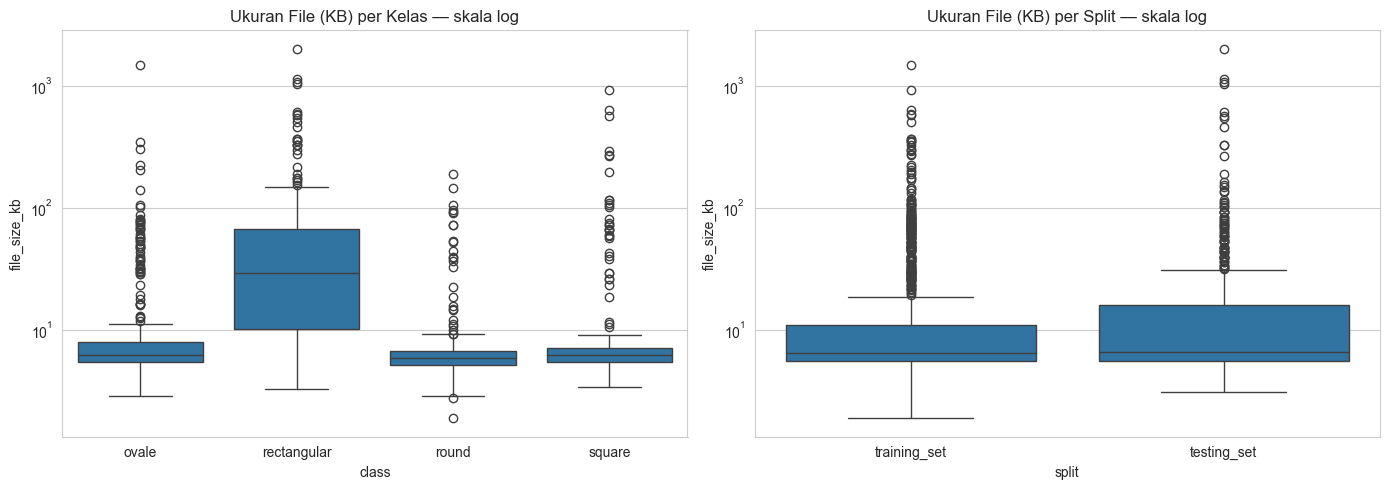

Jumlah outlier ukuran file (IQR method): 265 dari 1312


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="class", y="file_size_kb", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Ukuran File (KB) per Kelas — skala log")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=df, x="split", y="file_size_kb", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Ukuran File (KB) per Split — skala log")

plt.tight_layout()
plt.show()

# Outlier ukuran file (sangat besar / sangat kecil)
q1, q3 = df["file_size_kb"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["file_size_kb"] < q1 - 1.5*iqr) | (df["file_size_kb"] > q3 + 1.5*iqr)]
print(f"Jumlah outlier ukuran file (IQR method): {len(outliers)} dari {len(df)}")


---
## 6. Analisis Warna & Brightness

Mengambil sample per kelas untuk menghitung rata-rata brightness dan komposisi channel RGB —
berguna untuk tahu apakah ada kelas dengan karakteristik pencahayaan/warna yang berbeda mencolok.


In [10]:
def compute_color_stats(filepath, resize_to=64):
    with Image.open(filepath) as img:
        img = img.convert("RGB").resize((resize_to, resize_to))
        arr = np.array(img).astype(np.float32)
    r, g, b = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
    brightness = arr.mean()
    return pd.Series({"mean_r": r, "mean_g": g, "mean_b": b, "brightness": brightness})

# Sample maksimal 80 gambar per kelas biar cepat, tapi tetap representatif
sample_parts = []
for cls in sorted(df["class"].unique()):
    cls_df = df[df["class"] == cls]
    sample_parts.append(cls_df.sample(min(80, len(cls_df)), random_state=42))
sample_df = pd.concat(sample_parts, ignore_index=True)

color_stats = sample_df["filepath"].apply(compute_color_stats)
sample_df = pd.concat([sample_df.reset_index(drop=True), color_stats.reset_index(drop=True)], axis=1)

sample_df.groupby("class")[["mean_r","mean_g","mean_b","brightness"]].mean().round(1)


,mean_r,mean_g,mean_b,brightness
class,,,,
ovale,128.800003,115.199997,111.099998,118.400002
rectangular,132.500000,116.400002,111.000000,120.000000
round,126.900002,108.900002,103.599998,113.099998
square,127.900002,112.000000,109.500000,116.500000


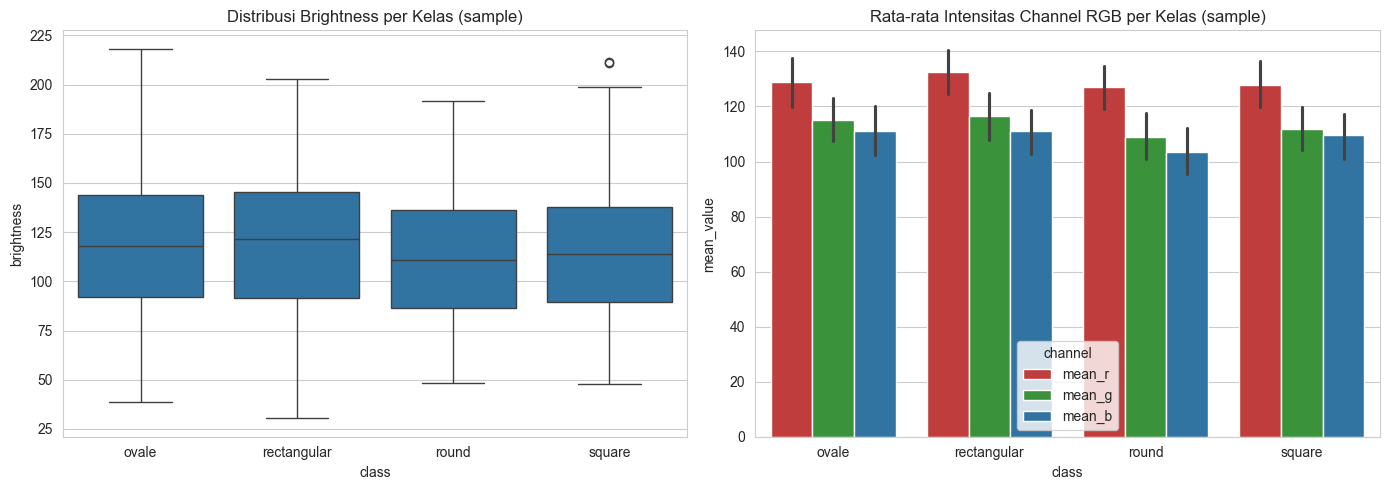

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sample_df, x="class", y="brightness", ax=axes[0])
axes[0].set_title("Distribusi Brightness per Kelas (sample)")
axes[0].tick_params(axis="x", rotation=0)

melted = sample_df.melt(id_vars="class", value_vars=["mean_r","mean_g","mean_b"],
                         var_name="channel", value_name="mean_value")
sns.barplot(data=melted, x="class", y="mean_value", hue="channel", ax=axes[1],
            palette={"mean_r":"#d62728", "mean_g":"#2ca02c", "mean_b":"#1f77b4"})
axes[1].set_title("Rata-rata Intensitas Channel RGB per Kelas (sample)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Insight:** Jika brightness/komposisi warna antar kelas jauh berbeda, model bisa jadi
"curang" belajar dari pencahayaan/warna background alih-alih bentuk wajah itu sendiri —
perlu diwaspadai saat augmentasi (color jitter) nanti di tahap modeling.

---
## 7. Kualitas Data: Duplikasi & Potensi Data Leakage

Menggunakan **MD5 hash** dari isi file untuk mendeteksi gambar yang benar-benar identik,
lalu memeriksa apakah ada duplikat lintas split atau dengan label berbeda.


In [12]:
def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(md5)
dup = df[df.duplicated("hash", keep=False)]

print(f"Grup gambar identik (duplikat exact): {dup['hash'].nunique()} grup, {len(dup)} file total")

if len(dup) > 0:
    leak = dup.groupby("hash")["split"].nunique()
    leak_across_split = leak[leak > 1]
    status_leak = "✅ Tidak ada leakage" if len(leak_across_split) == 0 else f"⚠️ ADA {len(leak_across_split)} GRUP LEAKAGE!"
    print(f"Duplikat lintas split (train<->test): {len(leak_across_split)}  {status_leak}")

    label_check = dup.groupby("hash")["class"].nunique()
    inconsistent = label_check[label_check > 1]
    status_label = "✅ Aman" if len(inconsistent) == 0 else f"⚠️ ADA {len(inconsistent)} GRUP LABEL NOISE!"
    print(f"Duplikat dengan label kelas berbeda: {len(inconsistent)}  {status_label}")

    if len(leak_across_split) > 0:
        print("\nDetail duplikat lintas split:")
        display(dup[dup["hash"].isin(leak_across_split.index)][["split","class","filename","hash"]].sort_values("hash"))
else:
    print("Tidak ditemukan duplikat exact di dataset ini.")


Grup gambar identik (duplikat exact): 58 grup, 121 file total
Duplikat lintas split (train<->test): 0  ✅ Tidak ada leakage
Duplikat dengan label kelas berbeda: 0  ✅ Aman


---
## 8. Cek Gambar Bermasalah (Sangat Kecil / Rasio Ekstrem)


In [13]:
tiny = df[(df["width"] < 50) | (df["height"] < 50)]
print(f"Gambar sangat kecil (<50px salah satu sisi): {len(tiny)}")
if len(tiny) > 0:
    display(tiny[["split","class","filename","width","height"]])

extreme_ratio = df[(df["aspect_ratio"] < 0.4) | (df["aspect_ratio"] > 2.5)]
print(f"\nGambar dengan aspect ratio ekstrem (<0.4 atau >2.5): {len(extreme_ratio)}")
if len(extreme_ratio) > 0:
    display(extreme_ratio[["split","class","filename","width","height","aspect_ratio"]])


Gambar sangat kecil (<50px salah satu sisi): 0

Gambar dengan aspect ratio ekstrem (<0.4 atau >2.5): 0


---
## 9. Contoh Gambar per Kelas


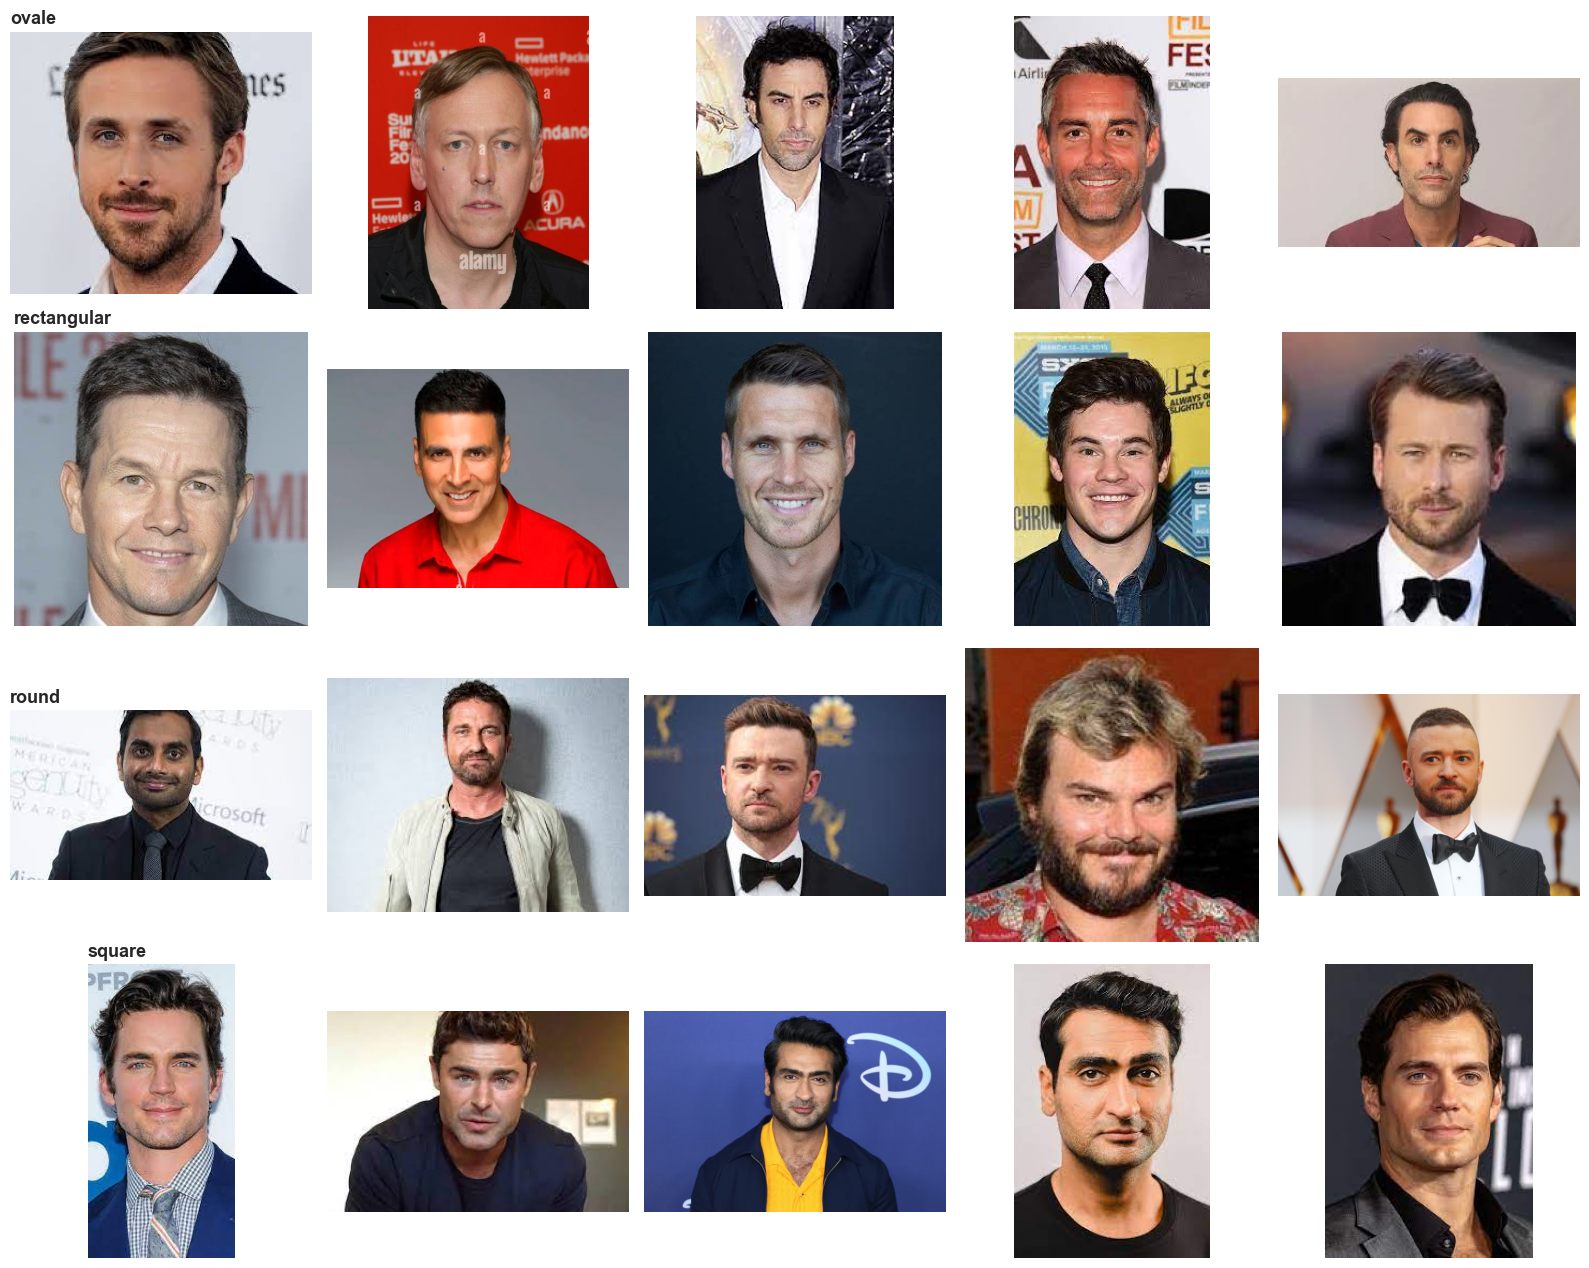

In [14]:
classes = sorted(df["class"].unique())
n_samples = 5

fig, axes = plt.subplots(len(classes), n_samples, figsize=(3.2 * n_samples, 3.2 * len(classes)))
for i, cls in enumerate(classes):
    samples = df[(df["class"] == cls) & (df["split"] == "training_set")].sample(
        min(n_samples, (df["class"] == cls).sum()), random_state=42
    )
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["filepath"])
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls, fontsize=13, fontweight="bold", loc="left")

plt.tight_layout()
plt.show()


---
## 10. Pixel Intensity Histogram (Sample)

Melihat distribusi intensitas piksel keseluruhan (grayscale) untuk beberapa sample gambar
dari tiap kelas — membantu mendeteksi apakah ada perbedaan kontras/eksposur mencolok antar kelas.


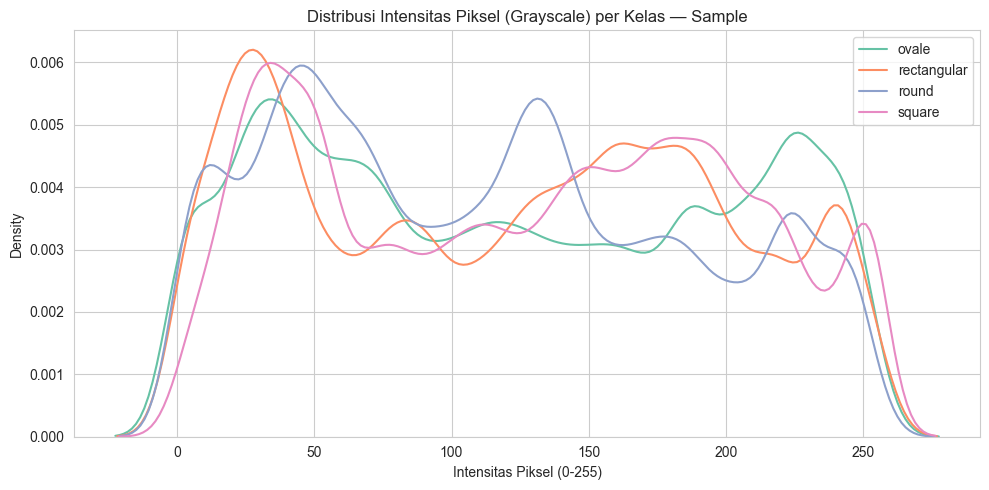

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(classes))

for cls, color in zip(classes, colors):
    sub = df[(df["class"] == cls) & (df["split"] == "training_set")].sample(
        min(30, (df["class"] == cls).sum()), random_state=42
    )
    all_pixels = []
    for fp in sub["filepath"]:
        with Image.open(fp) as img:
            gray = np.array(img.convert("L").resize((64, 64)))
            all_pixels.extend(gray.flatten())
    sns.kdeplot(all_pixels, label=cls, color=color, ax=ax)

ax.set_title("Distribusi Intensitas Piksel (Grayscale) per Kelas — Sample")
ax.set_xlabel("Intensitas Piksel (0-255)")
ax.legend()
plt.tight_layout()
plt.show()


---
## Ringkasan Temuan EDA

Isi ringkasan di bawah berdasarkan angka aktual yang muncul di cell-cell sebelumnya saat notebook
ini dijalankan pada dataset kamu:

| Aspek | Temuan |
|---|---|
| Total gambar valid | Lihat output Bagian 1 |
| Gambar corrupt | Lihat output Bagian 1 |
| Imbalance antar kelas | Lihat output Bagian 2 |
| Konsistensi split train/test | Lihat output Bagian 3 |
| Variasi resolusi | Lihat output Bagian 4 — kemungkinan besar sangat bervariasi |
| Duplikat & data leakage | Lihat output Bagian 7 |
| Gambar bermasalah (kecil/rasio ekstrem) | Lihat output Bagian 8 |

**Catatan:** Notebook ini murni eksplorasi — belum ada tindakan cleaning/modeling yang dilakukan di sini.
Jika ditemukan masalah (duplikat, leakage, ketidakseimbangan split, dll), tangani secara terpisah
sebelum lanjut ke tahap training model.
